In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
turn_full_peptide_asn = pd.read_csv('/data/mcohen3/CTD/analysis_data/turn_percents_final_asn.csv', index_col=0)
turn_full_peptide_con = pd.read_csv('/data/mcohen3/CTD/analysis_data/turn_percents_final_con.csv', index_col=0)

pro13turn_cis_asn = pd.read_csv('/data/mcohen3/CTD/analysis_data/pro13_turn_cis_percents_final_asn.csv', index_col=0)
pro13turn_cis_con = pd.read_csv('/data/mcohen3/CTD/analysis_data/pro13_turn_cis_percents_final_con.csv', index_col=0)

In [4]:
con_sim_weights = pd.read_csv('con_sim_weights.csv', index_col=0)
p_con_sim_weights = pd.read_csv('p_con_sim_weights.csv', index_col=0)

In [6]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

In [5]:
turn_full_peptide_con

,unphos,phos
0,0.106096,0.126448
1,0.111788,0.141494
2,0.119356,0.096252
3,0.105786,0.104154
4,0.117139,0.109452
5,0.113509,0.083889
6,0.107558,0.133662
7,0.116333,0.059119
8,0.115642,0.085406
9,0.110193,0.040141


In [8]:
turn_con = turn_full_peptide_con.iloc[:-2,0]
p_turn_con = turn_full_peptide_con.iloc[:-2,1]

In [18]:
pro13turn_cis_con

,unphos,phos
0,0.181186,0.268872
1,0.277494,0.259571
2,0.130583,0.162515
3,0.235963,0.242204
4,0.363914,0.233598
5,0.244515,0.000000
6,0.307302,0.795632
7,0.192216,0.000000
8,0.156050,0.000000
9,0.263646,0.000000


In [19]:
cis_con = pro13turn_cis_con.iloc[:-2,0]
p_cis_con = pro13turn_cis_con.iloc[:-2,1]

In [12]:
p_turn_con.values

array([0.12644818, 0.14149395, 0.09625217, 0.1041538 , 0.10945185,
       0.08388942, 0.13366174, 0.05911905, 0.08540557, 0.04014098])

In [15]:
p_con_sim_weights.iloc[:,0].values

array([1.99774433e-01, 1.99790189e-01, 2.00263293e-01, 1.99920542e-01,
       1.99614367e-01, 3.30227604e-25, 6.37175642e-04, 3.30227604e-25,
       3.30227604e-25, 3.30227604e-25])

In [16]:
weighted_mean_and_se(p_turn_con.values, p_con_sim_weights.iloc[:,0].values)

(0.11556180768747149, 0.008154085708415823)

In [17]:
weighted_mean_and_se(turn_con.values, con_sim_weights.iloc[:,0].values)

(0.11227996205875118, 0.0016254371129578477)

In [22]:
turn_full_peptide_con.loc['mean'] = [weighted_mean_and_se(turn_con.values, con_sim_weights.iloc[:,0].values)[0], weighted_mean_and_se(p_turn_con.values, p_con_sim_weights.iloc[:,0].values)[0]]

In [24]:
turn_full_peptide_con.loc['sem'] = [weighted_mean_and_se(turn_con.values, con_sim_weights.iloc[:,0].values)[1], weighted_mean_and_se(p_turn_con.values, p_con_sim_weights.iloc[:,0].values)[1]]

In [25]:
turn_full_peptide_con

,unphos,phos
0,0.106096,0.126448
1,0.111788,0.141494
2,0.119356,0.096252
3,0.105786,0.104154
4,0.117139,0.109452
5,0.113509,0.083889
6,0.107558,0.133662
7,0.116333,0.059119
8,0.115642,0.085406
9,0.110193,0.040141


In [20]:
weighted_mean_and_se(p_cis_con.values, p_con_sim_weights.iloc[:,0].values)

(0.2336773387111509, 0.02005465676281255)

In [21]:
weighted_mean_and_se(cis_con.values, con_sim_weights.iloc[:,0].values)

(0.23574296898481284, 0.023981394892860226)

In [26]:
pro13turn_cis_con.loc['mean'] = [weighted_mean_and_se(cis_con.values, con_sim_weights.iloc[:,0].values)[0], weighted_mean_and_se(p_cis_con.values, p_con_sim_weights.iloc[:,0].values)[0]]

In [27]:
pro13turn_cis_con.loc['sem'] = [weighted_mean_and_se(cis_con.values, con_sim_weights.iloc[:,0].values)[1], weighted_mean_and_se(p_cis_con.values, p_con_sim_weights.iloc[:,0].values)[1]]

In [28]:
pro13turn_cis_con

,unphos,phos
0,0.181186,0.268872
1,0.277494,0.259571
2,0.130583,0.162515
3,0.235963,0.242204
4,0.363914,0.233598
5,0.244515,0.000000
6,0.307302,0.795632
7,0.192216,0.000000
8,0.156050,0.000000
9,0.263646,0.000000


In [29]:
# Define column names
columns = ['Consensus', 'Asparagine']

# Create an empty DataFrame with 2 rows and 5 columns
turn_full_peptide_unphos = pd.DataFrame(np.nan, index=turn_full_peptide_asn.index, columns=columns)


In [30]:
turn_full_peptide_unphos['Consensus'] = turn_full_peptide_con['unphos']

In [31]:
turn_full_peptide_unphos['Asparagine'] = turn_full_peptide_asn['unphos']

In [32]:
turn_full_peptide_unphos

,Consensus,Asparagine
0,0.106096,0.107680
1,0.111788,0.097846
2,0.119356,0.107675
3,0.105786,0.103914
4,0.117139,0.104317
5,0.113509,0.111832
6,0.107558,0.110141
7,0.116333,0.094404
8,0.115642,0.093476
9,0.110193,0.108579


In [33]:
turn_full_peptide_phos = pd.DataFrame(np.nan, index=turn_full_peptide_asn.index, columns=columns)

In [34]:
turn_full_peptide_phos['Consensus'] = turn_full_peptide_con['phos']

In [35]:
turn_full_peptide_phos

,Consensus,Asparagine
0,0.126448,NaN
1,0.141494,NaN
2,0.096252,NaN
3,0.104154,NaN
4,0.109452,NaN
5,0.083889,NaN
6,0.133662,NaN
7,0.059119,NaN
8,0.085406,NaN
9,0.040141,NaN


In [36]:
turn_full_peptide_phos['Asparagine'] = turn_full_peptide_asn['phos']

(0.0, 15.0)

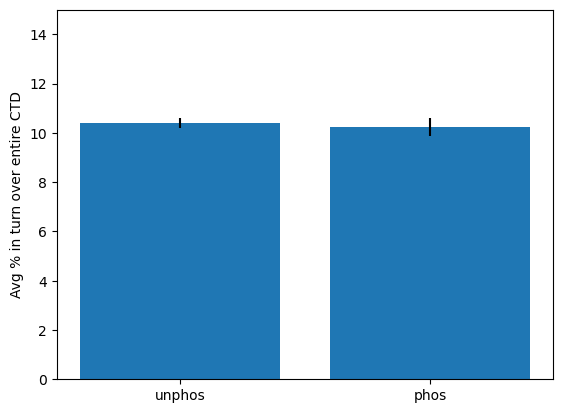

In [37]:
x = ["unphos","phos"]

x_axis = np.arange(len(x))

plt.bar(x_axis, turn_full_peptide_asn.loc['mean']*100, yerr = turn_full_peptide_asn.loc['sem']*100, label = 'Pro6 in Cis' )
#plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, label = 'Pro6 in Trans', color = 'blue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
#plt.legend(loc = "upper left", fontsize = 11, frameon = False)
plt.ylabel("Avg % in turn over entire CTD")
plt.ylim(top=15)  
plt.ylim(bottom=0)

(0.0, 15.0)

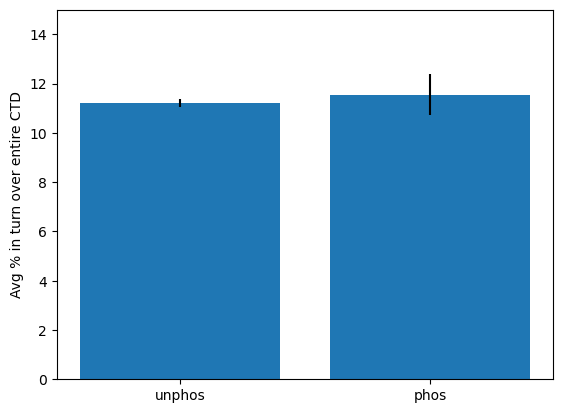

In [38]:
plt.bar(x_axis, turn_full_peptide_con.loc['mean']*100, yerr = turn_full_peptide_con.loc['sem']*100, label = 'Pro6 in Cis' )
#plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, label = 'Pro6 in Trans', color = 'blue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
#plt.legend(loc = "upper left", fontsize = 11, frameon = False)
plt.ylabel("Avg % in turn over entire CTD")
plt.ylim(top=15)  
plt.ylim(bottom=0)

(0.0, 15.0)

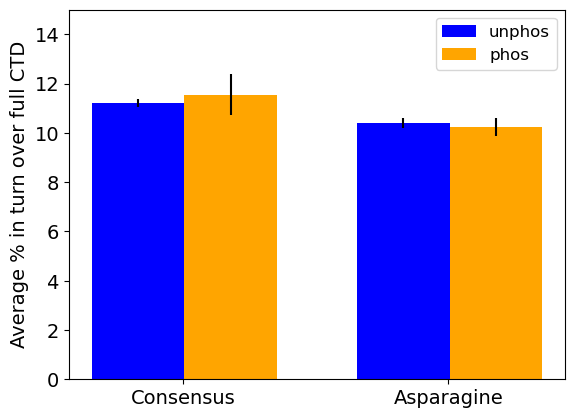

In [43]:
x = ["Consensus","Asparagine"]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.17, turn_full_peptide_unphos.loc['mean']*100, 0.35, yerr = turn_full_peptide_unphos.loc['sem']*100, label='unphos', color='blue')
plt.bar(x_axis + 0.18, turn_full_peptide_phos.loc['mean']*100, 0.35, yerr = turn_full_peptide_phos.loc['sem']*100, label='phos', color='orange')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper right", fontsize = 12)
plt.ylabel("Average % in turn over full CTD", fontsize = 14)
plt.ylim(top=15)  
plt.ylim(bottom=0)

In [40]:
# Define column names
columns = ['Consensus', 'Asparagine']

# Create an empty DataFrame with 2 rows and 5 columns
pro13turn_cis_unphos = pd.DataFrame(np.nan, index=pro13turn_cis_asn.index, columns=columns)
pro13turn_cis_phos = pd.DataFrame(np.nan, index=pro13turn_cis_asn.index, columns=columns)

In [41]:
pro13turn_cis_unphos['Asparagine'] = pro13turn_cis_asn['unphos']
pro13turn_cis_phos['Asparagine'] = pro13turn_cis_asn['phos']
pro13turn_cis_phos['Consensus'] = pro13turn_cis_con['phos']
pro13turn_cis_unphos['Consensus'] = pro13turn_cis_con['unphos']

(0.0, 50.0)

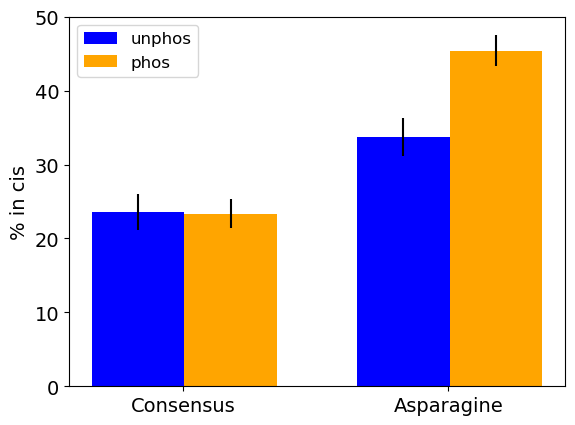

In [44]:
x = ["Consensus","Asparagine"]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.17, pro13turn_cis_unphos.loc['mean']*100, 0.35, yerr = pro13turn_cis_unphos.loc['sem']*100, label='unphos', color='blue')
plt.bar(x_axis + 0.18, pro13turn_cis_phos.loc['mean']*100, 0.35, yerr = pro13turn_cis_phos.loc['sem']*100, label='phos', color='orange')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("% in cis", fontsize = 14)
plt.ylim(top=50)  
plt.ylim(bottom=0)